<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/bionomial_distribution_without_scipy_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
''' bionomial distribution without using numoy and scipy module'''

In [26]:
import math
import numpy as np
import matplotlib.pyplot as plt


def comb_nCk(N,K):
  M = N-K
  combination = math.factorial(N)/(math.factorial(M)*math.factorial(K))
  return combination


# bionm of p(k) = c(n,k)*p^k*(1-p)^(n-k)
# check number_of_sucess is list or integer
def bionomial_pmf(trails,probability,number_of_sucess):
  probability_of_success = []
  if isinstance(number_of_sucess,int):
    combination = comb_nCk(trails,number_of_sucess)
    prob_for_each_success = combination*(probability**number_of_sucess)*(1-probability)**(trails-number_of_sucess)
    return prob_for_each_success
  else:
    for each_success in number_of_sucess:
      combination = comb_nCk(trails,each_success)
      prob_for_each_success = combination*(probability**each_success)*(1-probability)**(trails-each_success)
      probability_of_success.append(prob_for_each_success)
    return probability_of_success

# cdf is summation of bionomial c(n,k)*p^k*(1-p)^(n-k), range(0,k)
def bionomial_cdf(n1,p1,k1):
  pmf = bionomial_pmf(n1,p1,k1)
  cdf = []
  indv_pmf = 0
  for i in pmf:
    indv_pmf += i
    cdf.append(indv_pmf)
  return cdf



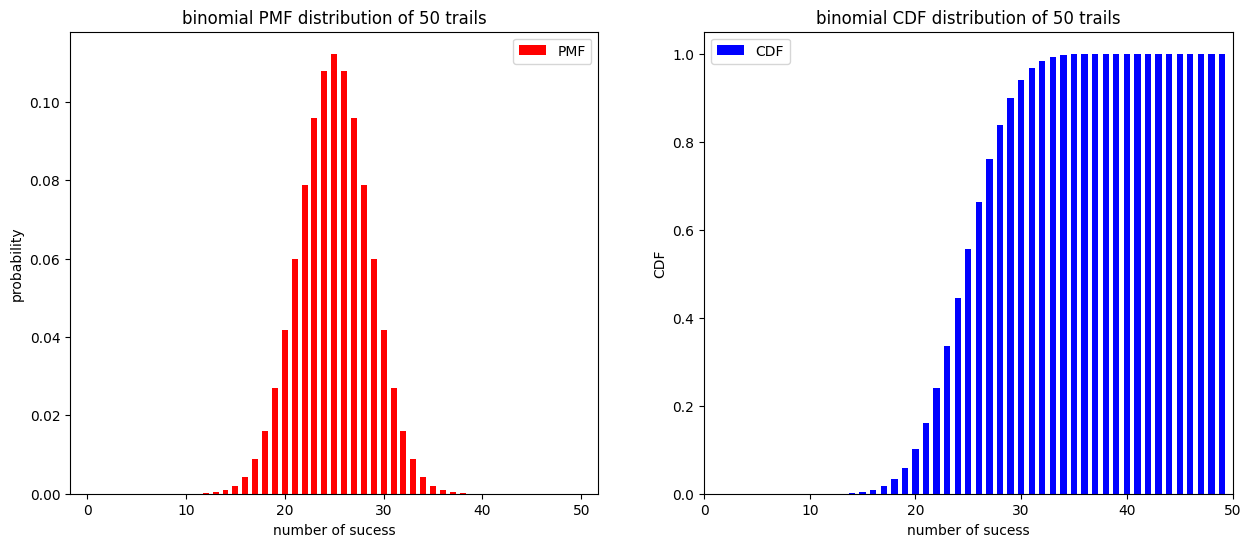

In [63]:
n = 50 # number of trails
k = np.arange(1,50).tolist() # number of success
p = 0.5

# probability mass function
pmf = bionomial_pmf(n,p,k)
cdf = bionomial_cdf(n,p,k)


# visualize this
w = 0.6
fig, axes = plt.subplots(1,2,figsize = (15,6))

axes[0].bar(k,pmf,width = w,color = 'red',label = 'PMF')
axes[0].set_xlabel('number of sucess')
axes[0].set_ylabel('probability')
axes[0].set_title(f'binomial PMF distribution of {n} trails')
axes[0].legend()

axes[1].bar(k,cdf,width = w,color = 'blue',label = 'CDF')
axes[1].set_xlabel('number of sucess')
axes[1].set_ylabel('CDF')
axes[1].set_title(f'binomial CDF distribution of {n} trails')
axes[1].legend()
plt.xlim(0,50)
plt.xticks()
plt.show()